In [41]:
import pandas as pd
import os

articles = pd.read_csv('../raw_data/articles_filtered.csv')
articles['index_group_name'].value_counts()
articles_lw = articles[articles['index_group_name'] == 'Ladieswear']
articles_lw.head(15)

,Unnamed: 0,article_id,product_code,prod_name,product_type_no,product_type_name,product_group_name,graphical_appearance_no,graphical_appearance_name,colour_group_code,...,department_name,index_code,index_name,index_group_no,index_group_name,section_no,section_name,garment_group_no,garment_group_name,detail_desc
17,1425,349301001,349301,GLASSIG ESPADRILLE,86,Ballerinas,Shoes,1010016,Solid,9,...,Flats,C,Ladies Accessories,1,Ladieswear,64,Womens Shoes,1020,Shoes,Espadrilles in cotton with a braided jute trim...
22,1430,349301022,349301,GLASSIG ESPADRILLE,86,Ballerinas,Shoes,1010016,Solid,42,...,Flats,C,Ladies Accessories,1,Ladieswear,64,Womens Shoes,1020,Shoes,Espadrilles in cotton with a braided jute trim...
24,1432,349301024,349301,GLASSIG ESPADRILLE,86,Ballerinas,Shoes,1010016,Solid,52,...,Flats,C,Ladies Accessories,1,Ladieswear,64,Womens Shoes,1020,Shoes,Espadrilles in cotton with a braided jute trim...
25,1433,349301025,349301,GLASSIG ESPADRILLE,86,Ballerinas,Shoes,1010016,Solid,10,...,Flats,C,Ladies Accessories,1,Ladieswear,64,Womens Shoes,1020,Shoes,Espadrilles in cotton with a braided jute trim...
26,1434,349301028,349301,GLASSIG ESPADRILLE,86,Ballerinas,Shoes,1010001,All over pattern,73,...,Flats,C,Ladies Accessories,1,Ladieswear,64,Womens Shoes,1020,Shoes,Espadrilles in cotton with a braided jute trim...
27,1435,349301029,349301,GLASSIG ESPADRILLE,86,Ballerinas,Shoes,1010001,All over pattern,51,...,Flats,C,Ladies Accessories,1,Ladieswear,64,Womens Shoes,1020,Shoes,Espadrilles in cotton with a braided jute trim...
28,1436,349301030,349301,GLASSIG ESPADRILLE,86,Ballerinas,Shoes,1010001,All over pattern,22,...,Flats,C,Ladies Accessories,1,Ladieswear,64,Womens Shoes,1020,Shoes,Espadrilles in cotton with a braided jute trim...
29,1437,349301032,349301,GLASSIG ESPADRILLE,86,Ballerinas,Shoes,1010016,Solid,42,...,Flats,C,Ladies Accessories,1,Ladieswear,64,Womens Shoes,1020,Shoes,Espadrilles in cotton with a braided jute trim...
30,1438,349301040,349301,GLASSIG ESPADRILLE,86,Ballerinas,Shoes,1010001,All over pattern,13,...,Flats,C,Ladies Accessories,1,Ladieswear,64,Womens Shoes,1020,Shoes,Espadrilles in cotton with a braided jute trim...
31,1439,349301041,349301,GLASSIG ESPADRILLE,86,Ballerinas,Shoes,1010001,All over pattern,11,...,Flats,C,Ladies Accessories,1,Ladieswear,64,Womens Shoes,1020,Shoes,Espadrilles in cotton with a braided jute trim...


In [29]:
def load_data(csv_path, images_base):

    articles = pd.read_csv(csv_path)
    print(articles['index_group_name'].value_counts())

    # Drop rows where index_group_name is 'Sport'
    value_counts = articles['index_group_name'].value_counts()
    rare_classes = value_counts[value_counts < 10].index.tolist()

    articles = articles[~articles['index_group_name'].isin(rare_classes)].reset_index(drop=True)

    def get_image_path(article_id):
        article_str = str(article_id).zfill(10)
        folder = article_str[:3]
        img_file = os.path.join(images_base, folder, f"{article_str}.jpg")
        return img_file if os.path.exists(img_file) else None

    articles['image_path'] = articles['article_id'].apply(get_image_path)
    articles = articles.dropna(subset=['image_path'])

    return articles


index_group_name
Baby/Children    2180
Ladieswear       2051
Menswear          661
Divided           263
Sport               1
Name: count, dtype: int64

=== Divided (263 images) ===


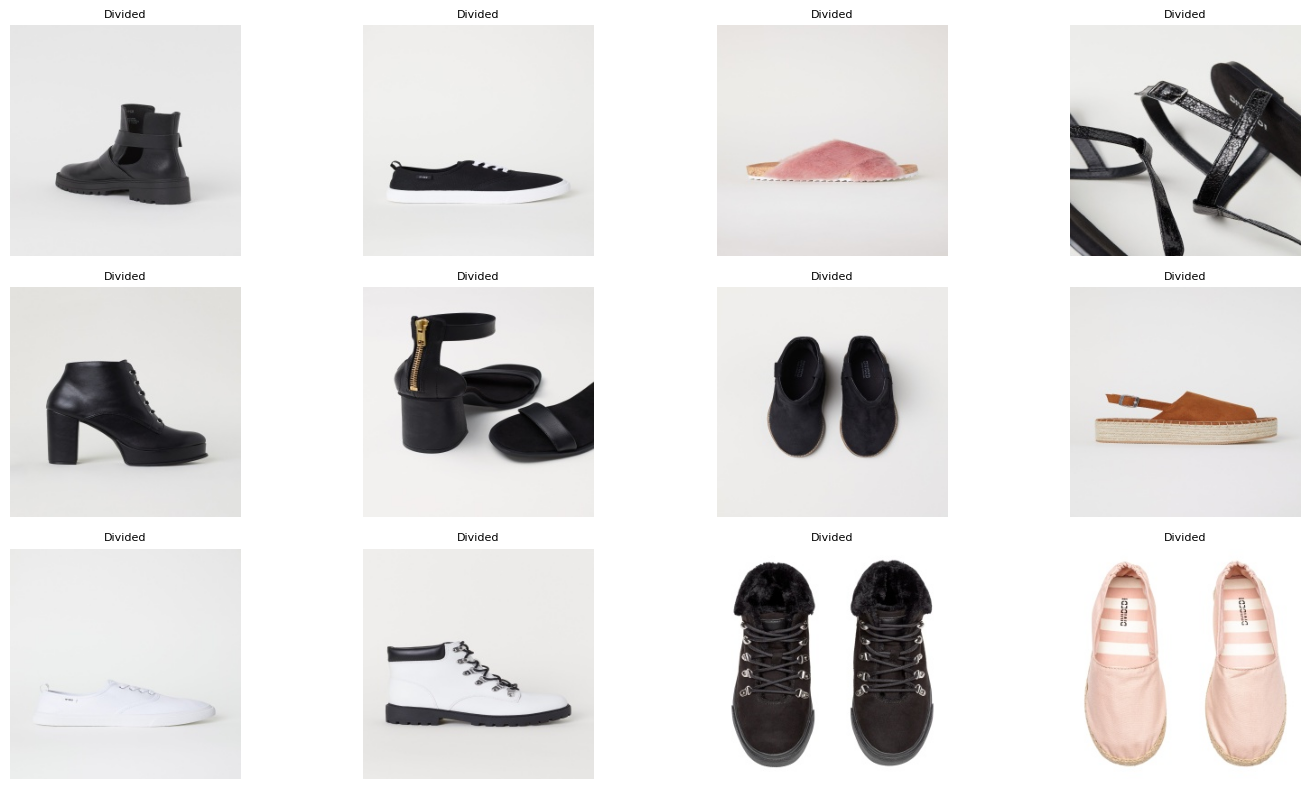


=== Menswear (661 images) ===


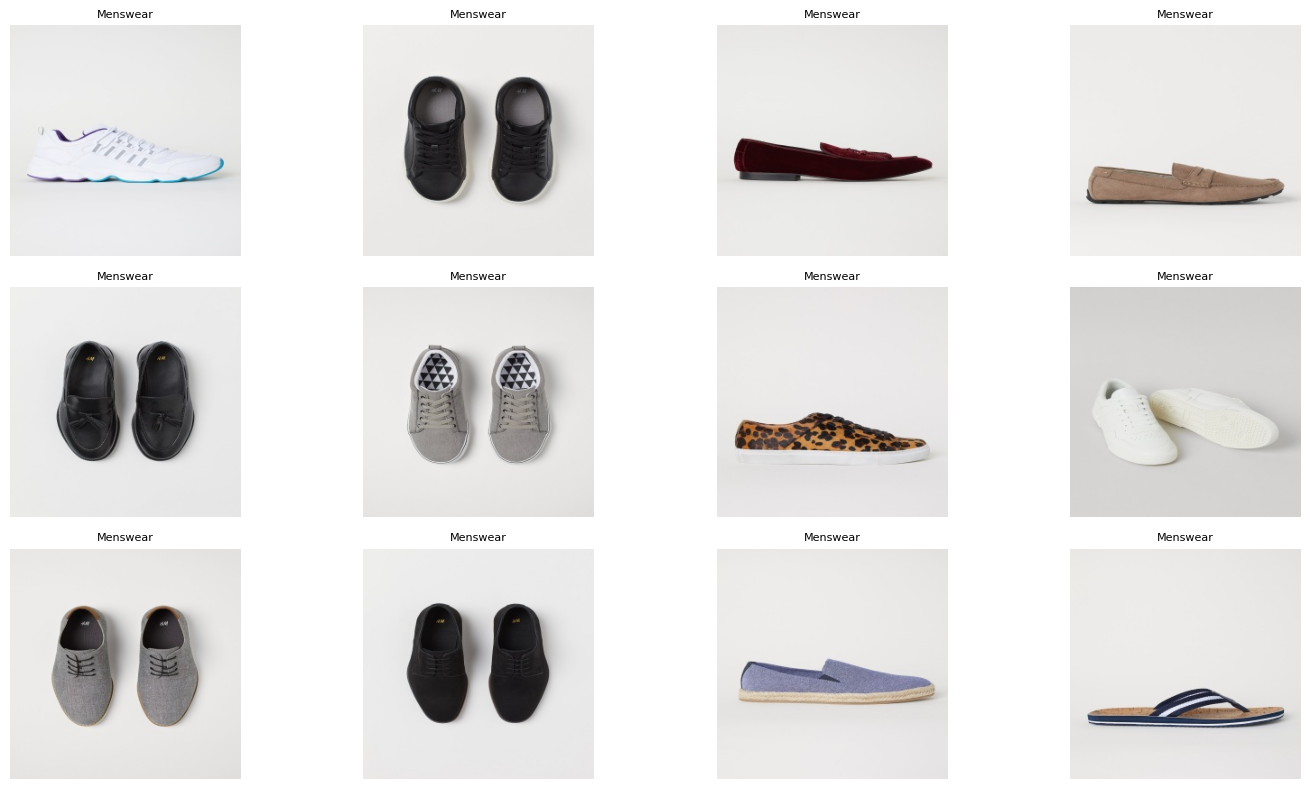


=== Ladieswear (2051 images) ===


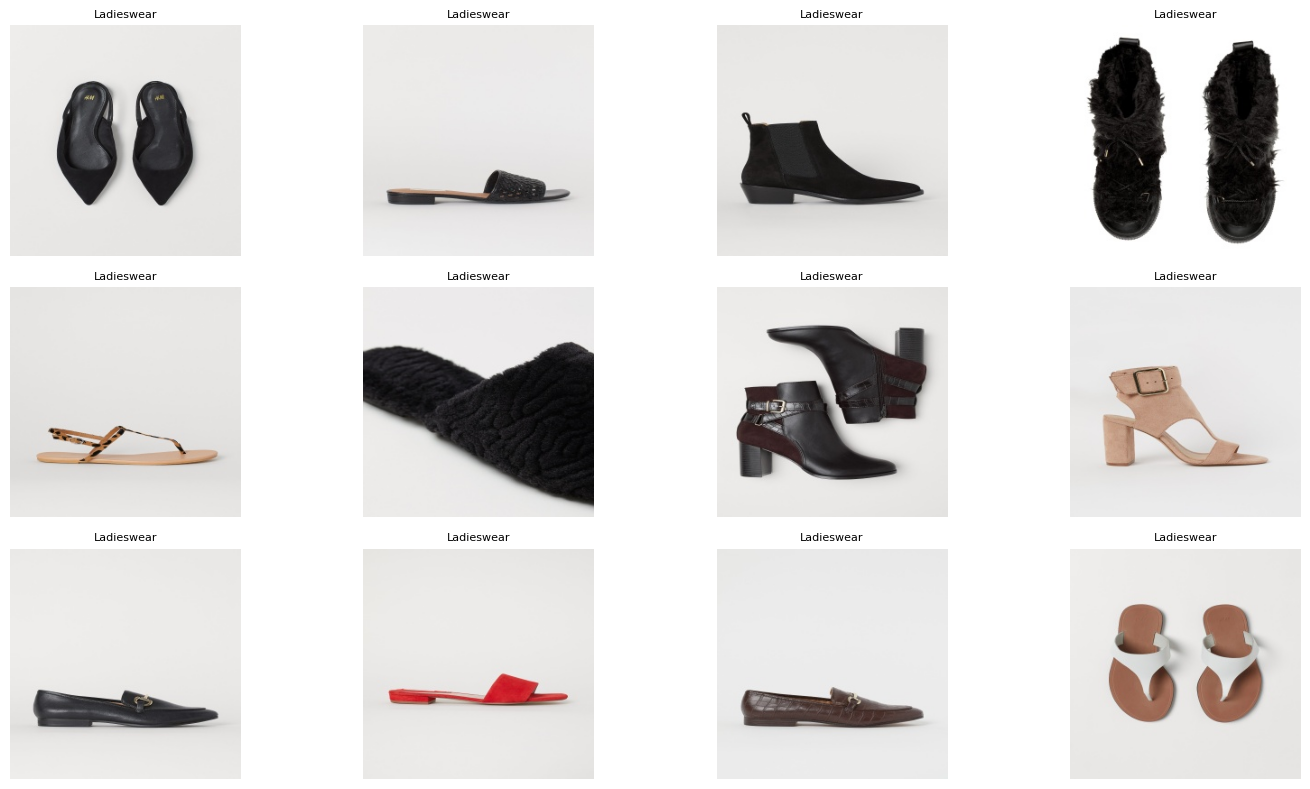


=== Baby/Children (2180 images) ===


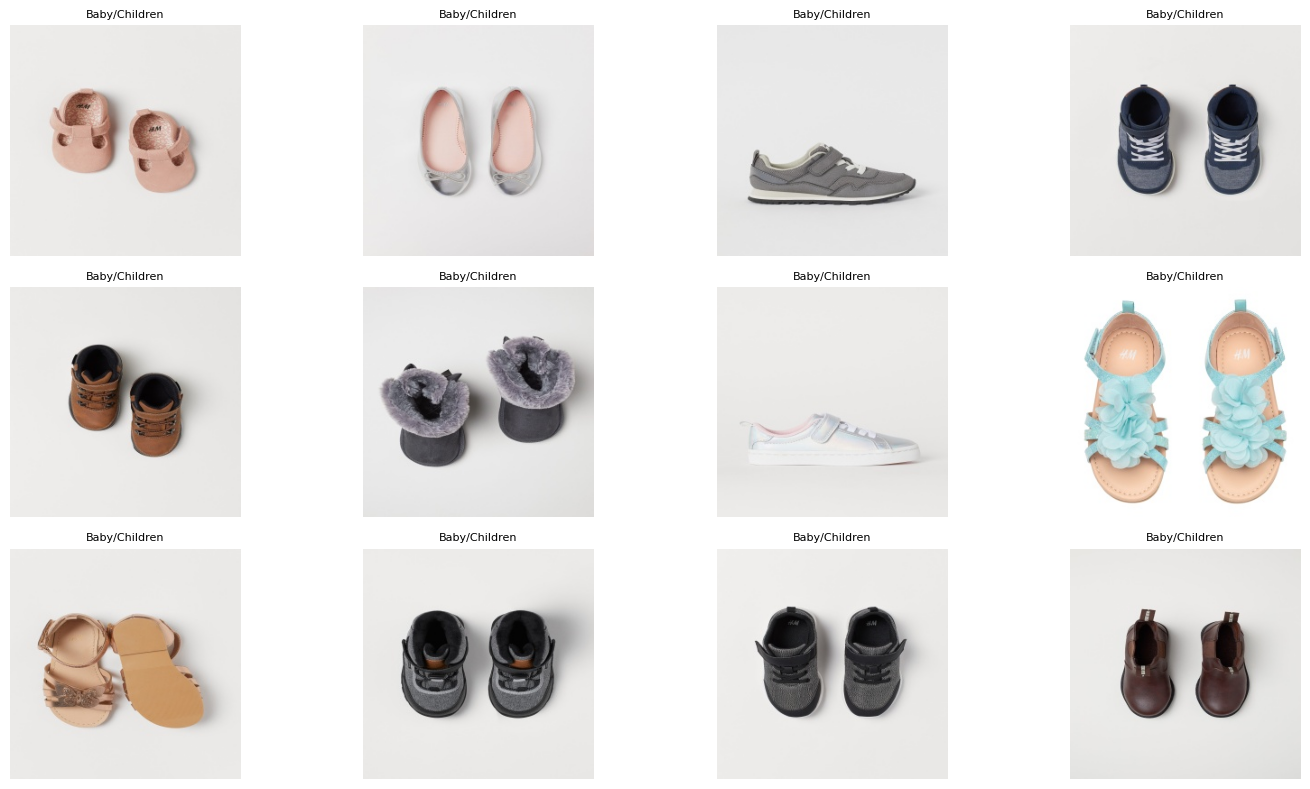

In [ ]:
import random
import matplotlib.pyplot as plt
import pandas as pd
from PIL import Image

articles = load_data('../raw_data/articles_filtered.csv',
                     images_base='../raw_data/images_filtered')

def show_random_images(df, label_col="index_group_name", path_col="image_path", n=12):
    labels = df[label_col].unique()

    for label in labels:
        subset = df[df[label_col] == label]
        print(f"\n=== {label} ({len(subset)} images) ===")

        sample_paths = subset[path_col].sample(min(n, len(subset))).tolist()

        plt.figure(figsize=(15, 8))
        for i, path in enumerate(sample_paths):
            try:
                img = Image.open(path).convert("RGB")
                plt.subplot(3, 4, i+1)
                plt.imshow(img)
                plt.title(label, fontsize=8)
                plt.axis("off")
            except Exception as e:
                print(f"Could not open {path}: {e}")
        plt.tight_layout()
        plt.show()

show_random_images(articles)


In [34]:
articles['exists'] = articles['image_path'].apply(lambda x: os.path.exists(x))
print("Valid images found:", articles['exists'].sum())
print("Rows in CSV:", len(articles))

Valid images found: 5155
Rows in CSV: 5155


In [36]:
articles_full = pd.read_csv('../raw_data/articles.csv')
articles.head()

,Unnamed: 0,article_id,product_code,prod_name,product_type_no,product_type_name,product_group_name,graphical_appearance_no,graphical_appearance_name,colour_group_code,...,index_name,index_group_no,index_group_name,section_no,section_name,garment_group_no,garment_group_name,detail_desc,image_path,exists
0,124,181160009,181160,Eva chelsea boot,87,Boots,Shoes,1010016,Solid,17,...,Divided,2,Divided,52,Divided Accessories,1020,Shoes,Chelsea boots with elasticated gores in the si...,../raw_data/images_filtered/018/0181160009.jpg,True
1,257,212042036,212042,Mimmi sneaker,94,Sneakers,Shoes,1010016,Solid,1,...,Divided,2,Divided,52,Divided Accessories,1020,Shoes,Cotton trainers with closed lacing and a loop ...,../raw_data/images_filtered/021/0212042036.jpg,True
2,260,212042070,212042,Mimmi sneaker,94,Sneakers,Shoes,1010016,Solid,10,...,Divided,2,Divided,52,Divided Accessories,1020,Shoes,Cotton trainers with closed lacing and a loop ...,../raw_data/images_filtered/021/0212042070.jpg,True
3,552,258650001,258650,Berlin boot,87,Boots,Shoes,1010016,Solid,9,...,Divided,2,Divided,52,Divided Accessories,1020,Shoes,Ankle boots in imitation suede with elastic go...,../raw_data/images_filtered/025/0258650001.jpg,True
4,571,264713001,264713,Al Car Shoe,89,Other shoe,Shoes,1010016,Solid,73,...,Menswear,3,Menswear,27,Men Shoes,1020,Shoes,Loafers in imitation suede with moccasin seams...,../raw_data/images_filtered/026/0264713001.jpg,True
